#### Let's start by performing an Exploratory Data Analysis on our dataset.

In [1]:
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv')

In [3]:
df.head()

,Date,"Fremont Bridge Sidewalks, south of N 34th St Total","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk"
0,10/02/2012 01:00:00 PM,55.0,7.0,48.0
1,10/02/2012 02:00:00 PM,130.0,55.0,75.0
2,10/02/2012 03:00:00 PM,152.0,81.0,71.0
3,10/02/2012 04:00:00 PM,278.0,167.0,111.0
4,10/02/2012 05:00:00 PM,563.0,393.0,170.0


In [4]:
df.shape

(110184, 4)

> _The dataset has 110,184 observations and 4 features_

In [5]:
# Number of elements
df.size

440736

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110184 entries, 0 to 110183
Data columns (total 4 columns):
 #   Column                                                              Non-Null Count   Dtype  
---  ------                                                              --------------   -----  
 0   Date                                                                110184 non-null  object 
 1   Fremont Bridge Sidewalks, south of N 34th St Total                  110156 non-null  float64
 2   Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk  110156 non-null  float64
 3   Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk  110156 non-null  float64
dtypes: float64(3), object(1)
memory usage: 3.4+ MB


>_We have some missing values, and our date column is an object; we need to change to a datetime type._

In [7]:
# using isnull() to confirm missing values
df.isnull().sum()

Date                                                                   0
Fremont Bridge Sidewalks, south of N 34th St Total                    28
Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk    28
Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk    28
dtype: int64

>_Deleting missing data using dropna()_

In [8]:
df.dropna(inplace=True)

df.isnull().sum()

Date                                                                  0
Fremont Bridge Sidewalks, south of N 34th St Total                    0
Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk    0
Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk    0
dtype: int64

In [9]:
# Use describe() to show summary statistics
df.describe()

,"Fremont Bridge Sidewalks, south of N 34th St Total","Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk","Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk"
count,110156.000000,110156.000000,110156.000000
mean,105.154581,44.831167,60.323414
std,130.736785,58.676107,81.581744
min,0.000000,0.000000,0.000000
25%,13.000000,5.000000,7.000000
50%,59.000000,25.000000,32.000000
75%,144.000000,62.000000,80.000000
max,1097.000000,667.000000,850.000000


#### Pre-processing dataset

>_To simplify our work, we will only use the total and date column._

In [10]:
df_total = df[['Date', 'Fremont Bridge Sidewalks, south of N 34th St Total']]

df_total.head()

,Date,"Fremont Bridge Sidewalks, south of N 34th St Total"
0,10/02/2012 01:00:00 PM,55.0
1,10/02/2012 02:00:00 PM,130.0
2,10/02/2012 03:00:00 PM,152.0
3,10/02/2012 04:00:00 PM,278.0
4,10/02/2012 05:00:00 PM,563.0


>_Rename the column Total_

In [11]:
df_total.rename({'Fremont Bridge Sidewalks, south of N 34th St Total' : 'Total'}, axis=1, inplace=True)

df_total.head()

C:\Users\serju\AppData\Local\Temp\ipykernel_24068\1630468625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total.rename({'Fremont Bridge Sidewalks, south of N 34th St Total' : 'Total'}, axis=1, inplace=True)


,Date,Total
0,10/02/2012 01:00:00 PM,55.0
1,10/02/2012 02:00:00 PM,130.0
2,10/02/2012 03:00:00 PM,152.0
3,10/02/2012 04:00:00 PM,278.0
4,10/02/2012 05:00:00 PM,563.0


In [12]:
# Change the type of Date column and sort values by date

df_total['Date'] = pd.to_datetime(df_total['Date'])

df_total = df_total.sort_values('Date')

df_total.info()

C:\Users\serju\AppData\Local\Temp\ipykernel_24068\2306583679.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_total['Date'] = pd.to_datetime(df_total['Date'])


<class 'pandas.core.frame.DataFrame'>
Index: 110156 entries, 0 to 110183
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    110156 non-null  datetime64[ns]
 1   Total   110156 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.5 MB


C:\Users\serju\AppData\Local\Temp\ipykernel_24068\2306583679.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['Date'] = pd.to_datetime(df_total['Date'])


>_Check for duplicate values and remove_

In [13]:
duplicates = df_total[df_total.duplicated()]

duplicates

,Date,Total
107352,2025-01-01 00:00:00,61.0
108769,2025-01-01 01:00:00,57.0
107354,2025-01-01 02:00:00,20.0
107355,2025-01-01 03:00:00,11.0
108772,2025-01-01 04:00:00,6.0
...,...,...
110179,2025-02-28 19:00:00,73.0
108764,2025-02-28 20:00:00,60.0
110181,2025-02-28 21:00:00,49.0
110182,2025-02-28 22:00:00,26.0


In [14]:
df_total = df_total.drop_duplicates(subset='Date', keep="last")

In [15]:
duplicates = df_total[df_total.duplicated()]

duplicates.shape

(0, 2)

In [16]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108740 entries, 0 to 110183
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    108740 non-null  datetime64[ns]
 1   Total   108740 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.5 MB


> _We're going to filter our dataset to work with data from the last 5 years 2020/2025, which I believe is sufficient for our analysis._

In [17]:
df_filter = df_total[df_total['Date'].dt.year >= 2020]

df_filter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45237 entries, 63515 to 110183
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    45237 non-null  datetime64[ns]
 1   Total   45237 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.0 MB


In [18]:
df_filter['Date'].min(), df_filter['Date'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2025-02-28 23:00:00'))

In [19]:
df_2025 = df_filter

df_2025.head()

,Date,Total
63515,2020-01-01 00:00:00,11.0
63516,2020-01-01 01:00:00,33.0
63517,2020-01-01 02:00:00,16.0
63518,2020-01-01 03:00:00,4.0
63519,2020-01-01 04:00:00,1.0


> _Set index using Date column_

In [20]:
df_2025.set_index('Date', inplace=True)

df_2025.head()

,Total
Date,
2020-01-01 00:00:00,11.0
2020-01-01 01:00:00,33.0
2020-01-01 02:00:00,16.0
2020-01-01 03:00:00,4.0
2020-01-01 04:00:00,1.0


In [21]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45237 entries, 2020-01-01 00:00:00 to 2025-02-28 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Total   45237 non-null  float64
dtypes: float64(1)
memory usage: 706.8 KB


> _Resample our dataset to hourly frequency, and use interpolation for NAN values_

In [22]:
df_hourly = df_2025.resample('h').interpolate()

df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45264 entries, 2020-01-01 00:00:00 to 2025-02-28 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Total   45264 non-null  float64
dtypes: float64(1)
memory usage: 707.2 KB


In [23]:
df_hourly.head()

,Total
Date,
2020-01-01 00:00:00,11.0
2020-01-01 01:00:00,33.0
2020-01-01 02:00:00,16.0
2020-01-01 03:00:00,4.0
2020-01-01 04:00:00,1.0


> _Extracting meaningful temporal and contextual features, such as hour of day, day of week, month, season._

In [24]:
df_hourly['hour'] = df_hourly.index.hour

df_hourly['day_of_week'] = df_hourly.index.dayofweek

df_hourly['month'] = df_hourly.index.month

df_hourly['year'] = df_hourly.index.year

In [25]:
df_hourly.head()

,Total,hour,day_of_week,month,year
Date,,,,,
2020-01-01 00:00:00,11.0,0,2,1,2020
2020-01-01 01:00:00,33.0,1,2,1,2020
2020-01-01 02:00:00,16.0,2,2,1,2020
2020-01-01 03:00:00,4.0,3,2,1,2020
2020-01-01 04:00:00,1.0,4,2,1,2020


>_Let's create a function to extract a feature for weekends and seasons._

In [26]:
def get_weekend(day):
    weekend=0
    if day >= 5:
        weekend=1
    else:
        weekend = 0
    return weekend
        

def season(month):
    
    match month:
        case 12 | 1 | 2:
            return 'winter'  # Match winter month
        case 3 | 4 | 5:
            return 'spring' # Match spring months
        case 6 | 7 | 8:
            return 'summer' # Match summer months
        case _:
            return 'fall' 

In [27]:
df_hourly['weekend'] = df_hourly['day_of_week'].apply(get_weekend)

df_hourly['season'] = df_hourly['month'].apply(season)


In [28]:
df_hourly.head()

,Total,hour,day_of_week,month,year,weekend,season
Date,,,,,,,
2020-01-01 00:00:00,11.0,0,2,1,2020,0,winter
2020-01-01 01:00:00,33.0,1,2,1,2020,0,winter
2020-01-01 02:00:00,16.0,2,2,1,2020,0,winter
2020-01-01 03:00:00,4.0,3,2,1,2020,0,winter
2020-01-01 04:00:00,1.0,4,2,1,2020,0,winter


#### Visualizing the data

>_Let’s start plotting the data to gain some insight!_

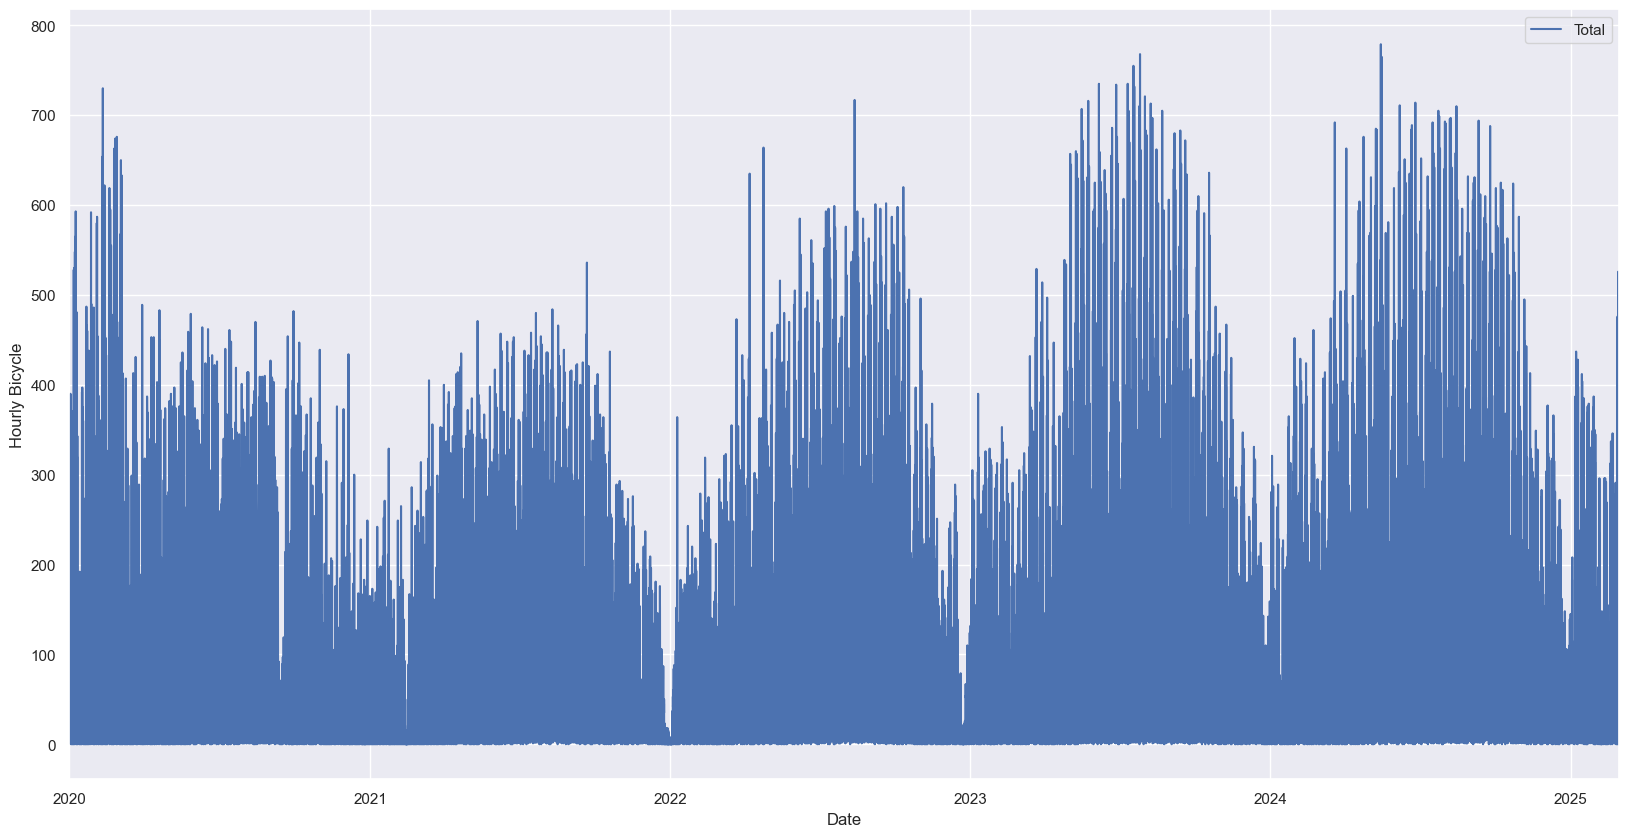

In [29]:
df_hourly['Total'].plot(figsize=(20, 10))
plt.legend(loc='best')
plt.ylabel("Hourly Bicycle")
plt.show()

>_Sum per week_

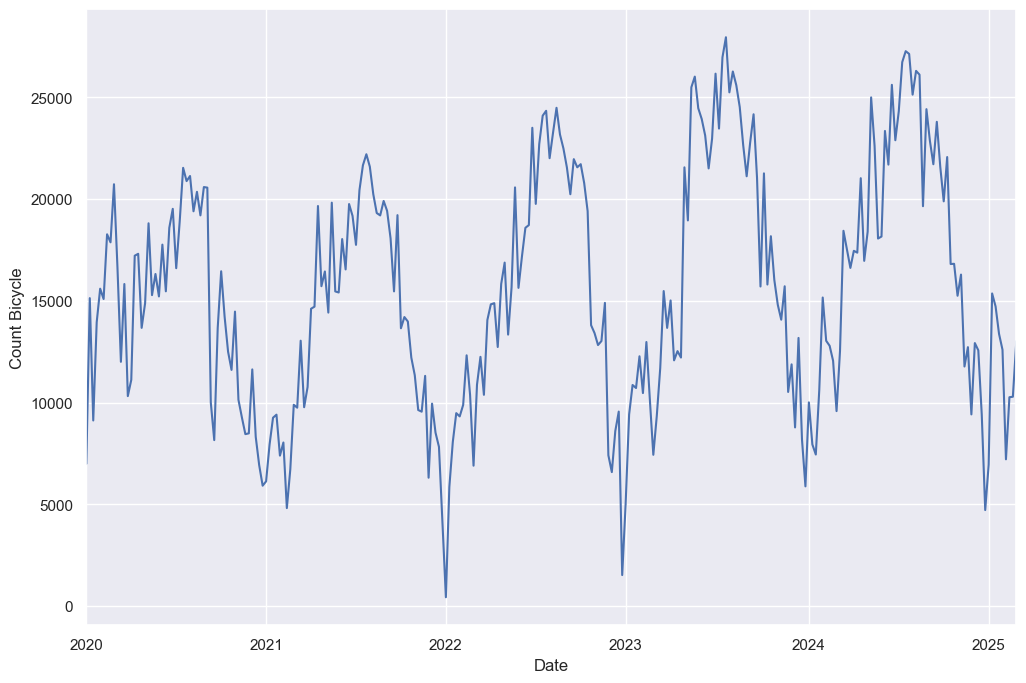

In [30]:
weekly = df_hourly['Total'].resample('w').sum()

plt.figure(figsize=(12, 8))
weekly.plot()
plt.ylabel('Count Bicycle');

>_Average daily_

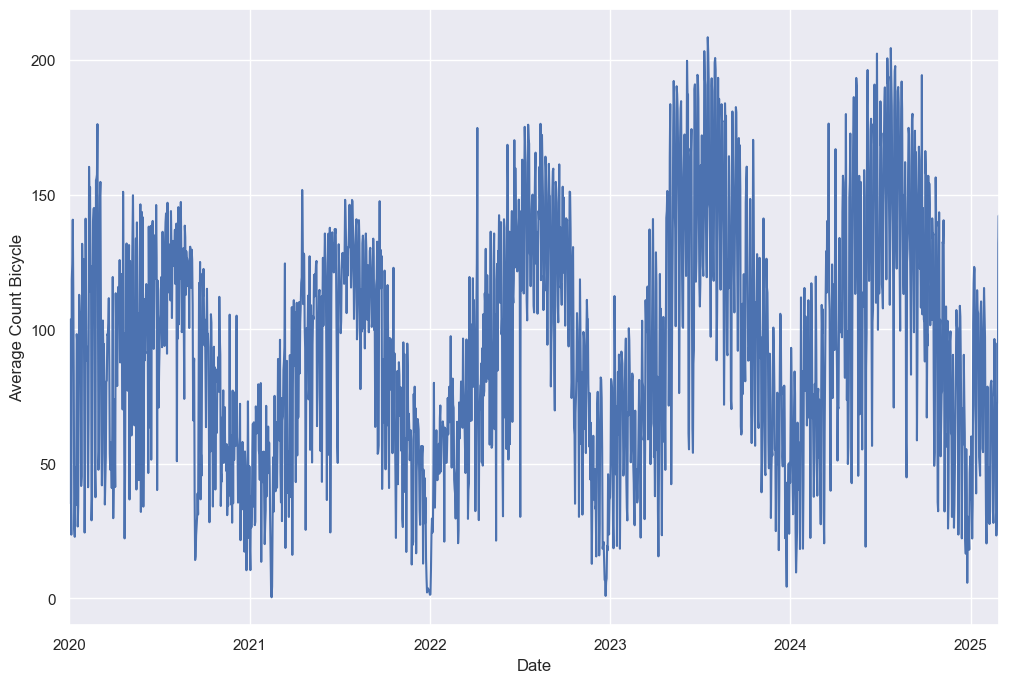

In [31]:
daily = df_hourly['Total'].resample('D').mean()

plt.figure(figsize=(12, 8))
daily.plot()
plt.ylabel('Average Count Bicycle');

>_Average by time of the day_

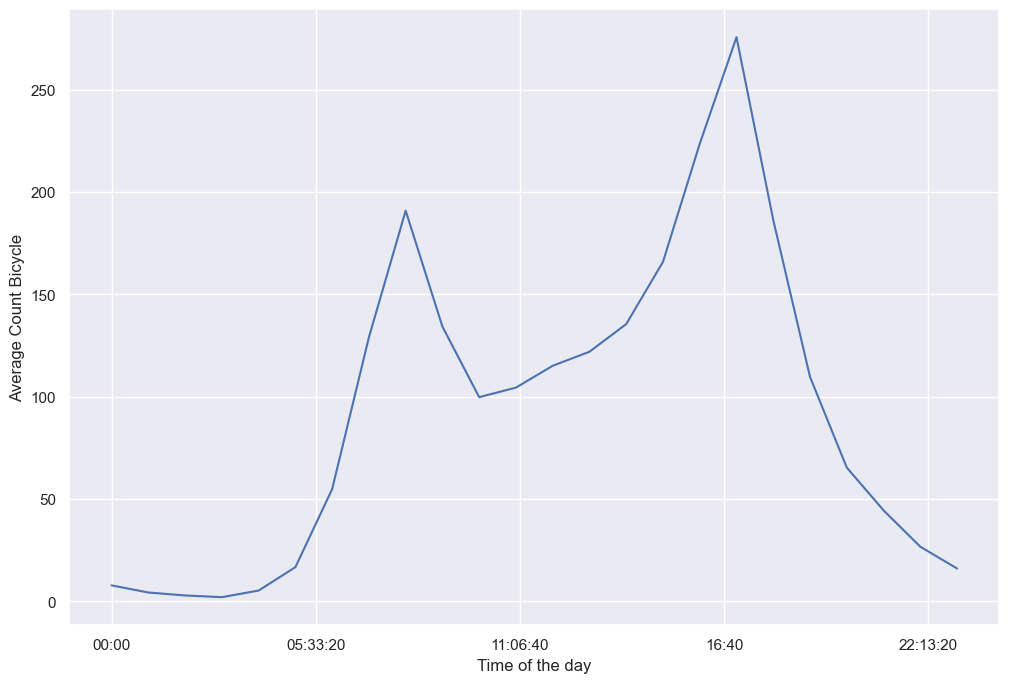

In [32]:
by_time_day = df_hourly['Total'].groupby(df_hourly['hour']).mean()
time_format = df_hourly['Total'].groupby(df_hourly.index.time).mean()

by_time_day.index = time_format.index

plt.figure(figsize=(12, 8))
plt.ylabel('Average Count Bicycle');
plt.xlabel('Time of the day');
by_time_day.plot();

>_Average by_weekday_

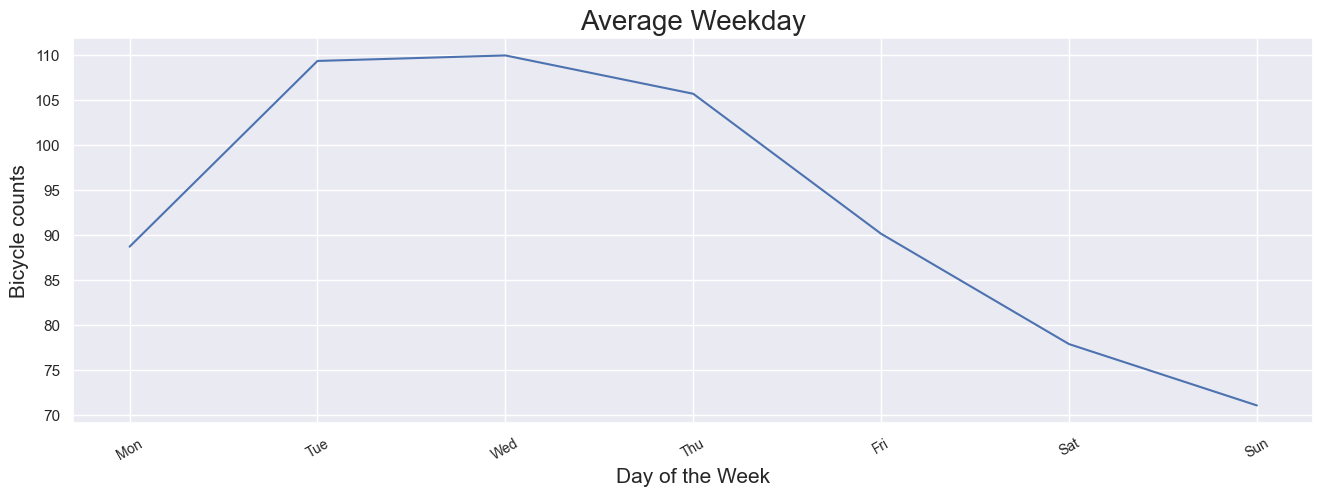

In [33]:
weekday = df_hourly['Total'].groupby(df_hourly['day_of_week']).mean()

# figure size
fig = plt.subplots(figsize=(16, 5))

plt.plot(weekday)

plt.title('Average Weekday', fontsize=20)

plt.xlabel('Day of the Week', fontsize=15)
plt.ylabel('Bicycle counts', fontsize=15)

tickvalues = weekday.index
tickslabel = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.xticks(ticks = tickvalues, labels=tickslabel, rotation=30, fontsize=10);

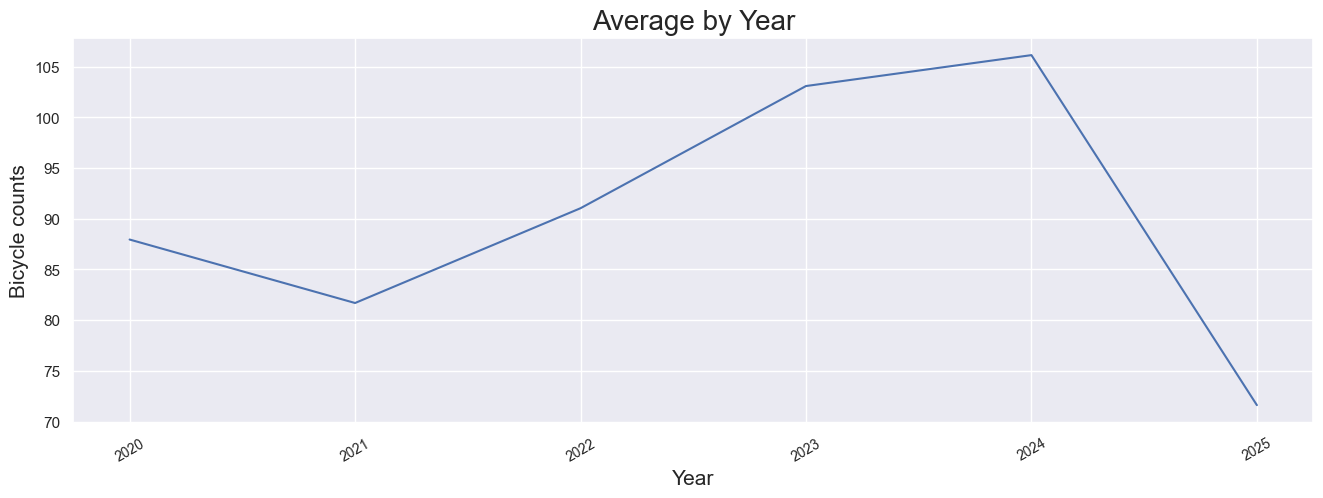

In [34]:
avg_year = df_hourly['Total'].groupby(df_hourly['year']).mean()

# figure size
fig = plt.subplots(figsize=(16, 5))

plt.plot(avg_year)

plt.title('Average by Year', fontsize=20)

plt.xlabel('Year', fontsize=15)
plt.ylabel('Bicycle counts', fontsize=15)

tickvalues = avg_year.index
plt.xticks(ticks = tickvalues, rotation=30, fontsize=10);

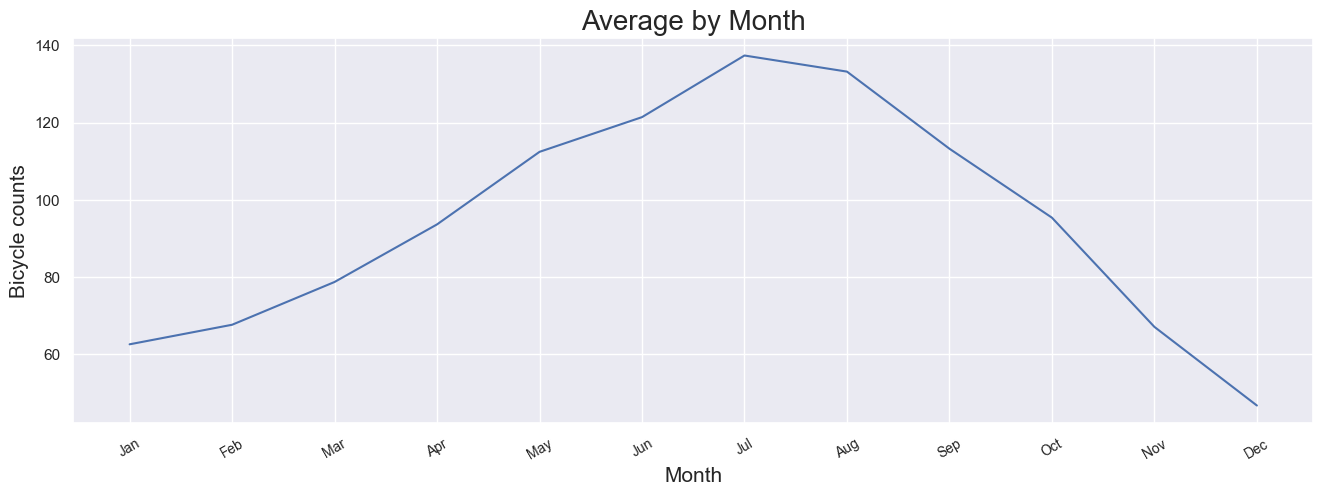

In [35]:
avg_month = df_hourly['Total'].groupby(df_hourly['month']).mean()

# figure size
fig = plt.subplots(figsize=(16, 5))

plt.plot(avg_month)

plt.title('Average by Month', fontsize=20)

plt.xlabel('Month', fontsize=15)
plt.ylabel('Bicycle counts', fontsize=15)

tickvalues = avg_month.index
tickslabel = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks = tickvalues, labels=tickslabel, rotation=30, fontsize=10);

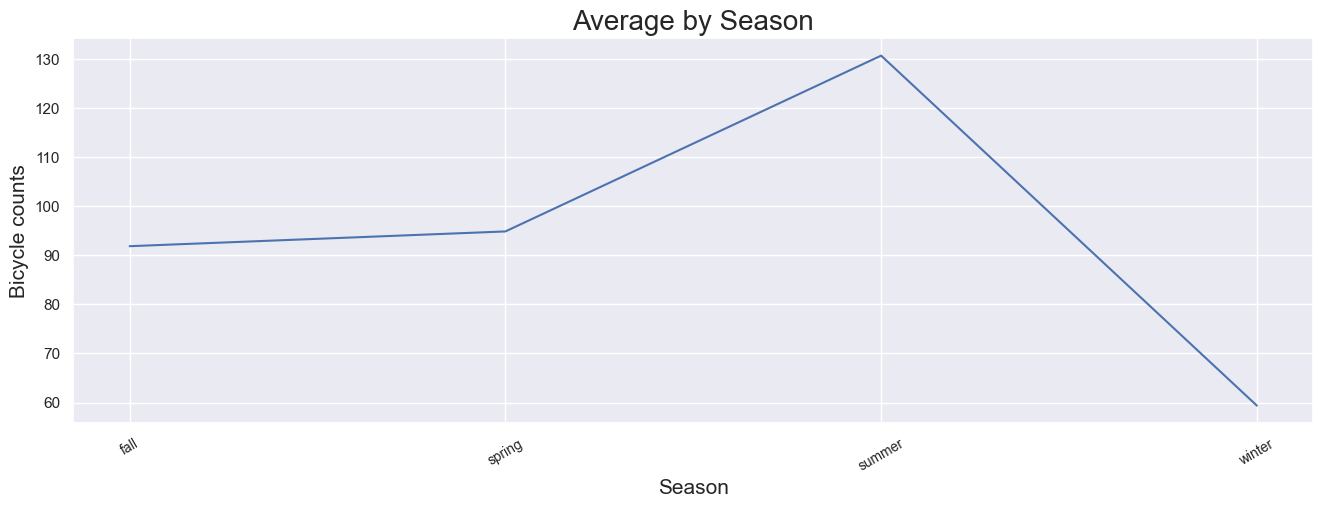

In [36]:
avg_season = df_hourly['Total'].groupby(df_hourly['season']).mean()

# figure size
fig = plt.subplots(figsize=(16, 5))

plt.plot(avg_season)

plt.title('Average by Season', fontsize=20)

plt.xlabel('Season', fontsize=15)
plt.ylabel('Bicycle counts', fontsize=15)

tickvalues = avg_season.index
tickslabel = ['fall', 'spring', 'summer', 'winter']
plt.xticks(ticks = tickvalues, labels=tickslabel, rotation=30, fontsize=10);

> __At this point, we save the dataset used for exploratory data analysis, preprocessing, and feature creation to CSV format. This is because we need to load our dataframe using _Visual Studio Code_ to create our dashboard using _Streamlit_.__

In [45]:
df_hourly.to_csv('df_fremont.csv')